# MCMC sampling

How to draw samples from a model's parameter posterior with mixle. This is the syntax tutorial; for the statistics (Metropolis-Hastings vs HMC, effective sample size, posterior-predictive uncertainty) see the data-science notebook mcmc_uncertainty_quantification.


In [1]:
import numpy as np
from mixle.stats import GaussianDistribution, PoissonDistribution, CategoricalDistribution, GammaDistribution
from mixle.inference.mcmc import (sample_parameter_posterior, sample_conjugate_posterior,
                             metropolis_hastings, hamiltonian_monte_carlo,
                             RandomWalkProposal, AdaptiveRandomWalkProposal,
                             build_parameter_bridge, posterior_predictive)

data = GaussianDistribution(1.0, 2.0).sampler(seed=0).sample(120)

## `sample_parameter_posterior` - general MCMC

Pass a prototype distribution (sets the family and the parameters to sample) and the data. `sampler='mh'` is random-walk Metropolis-Hastings; `'hmc'` is Hamiltonian Monte Carlo. Returns an `MCMCResult`.


In [2]:
res = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data,
                                 sampler='mh', steps=2000, burn_in=500, seed=1)

print('acceptance rate     :', round(res.acceptance_rate, 3))
draws = res.sample_array()                     # (n_kept, n_params); columns (mu, sigma2)
print('draws shape         :', draws.shape)
print('posterior mean      :', draws.mean(axis=0).round(3))
print('effective sample size:', np.round(res.effective_sample_size(), 0))

acceptance rate     : 0.645
draws shape         : (2000, 2)
posterior mean      : [1.171 2.269]
effective sample size: [146.  94.]


The draws are the posterior - plotting them shows the chain mixing and the joint uncertainty in `(µ, σ²)`:


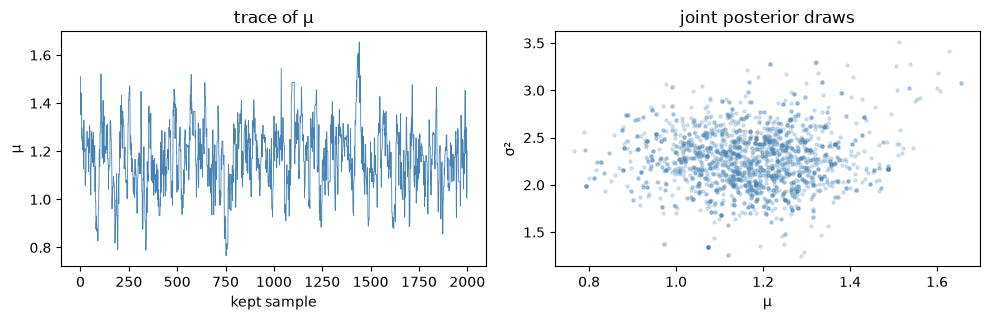

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

D = res.sample_array()                       # (n_kept, 2): columns (mu, sigma2)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].plot(D[:, 0], lw=0.6, color='steelblue')
ax[0].set_title('trace of µ'); ax[0].set_xlabel('kept sample'); ax[0].set_ylabel('µ')
ax[1].scatter(D[:, 0], D[:, 1], s=5, alpha=0.2, color='steelblue')
ax[1].set_xlabel('µ'); ax[1].set_ylabel('σ²'); ax[1].set_title('joint posterior draws')
plt.tight_layout(); plt.show()

`summary()` returns means, quantiles, ESS, and acceptance in one dict; `return_distributions=True` maps each draw back to a rebuilt distribution object instead of a parameter row.


In [4]:
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in res.summary().items()
       if k in ('acceptance_rate', 'num_samples')})

res_d = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data,
                                   sampler='mh', steps=800, burn_in=200, seed=1,
                                   return_distributions=True)
print('first drawn distribution:', res_d.samples[0])

{'num_samples': 2000, 'acceptance_rate': 0.645}
first drawn distribution: GaussianDistribution(1.232511584707523, 2.587679793870849, name=None, keys=None)


HMC takes the same call with a step size and leapfrog count:


In [5]:
hmc = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data,
                                 sampler='hmc', steps=1000, burn_in=200, seed=2,
                                 step_size=0.02, num_steps=15)
print('HMC acceptance:', round(hmc.acceptance_rate, 3), '| mean:', hmc.sample_array().mean(axis=0).round(3))

HMC acceptance: 1.0 | mean: [1.186 2.278]


Supported prototype families: Gaussian, Gamma, Exponential, Poisson, Bernoulli, Beta, and Categorical. Constrained parameters stay in-domain automatically - a Categorical's draws are valid probability vectors (each `samples` entry is a dict keyed by category):


In [6]:
cat = sample_parameter_posterior(
    CategoricalDistribution({'a': 1/3, 'b': 1/3, 'c': 1/3}),
    CategoricalDistribution({'a': 0.2, 'b': 0.5, 'c': 0.3}).sampler(seed=7).sample(150),
    sampler='mh', steps=1500, burn_in=400, seed=9)
P = np.array([[s[k] for k in ('a', 'b', 'c')] for s in cat.samples])
print('every draw is a valid simplex:', np.allclose(P.sum(axis=1), 1.0))
print('posterior mean probabilities :', P.mean(axis=0).round(3))

every draw is a valid simplex: True
posterior mean probabilities : [0.198 0.486 0.317]


## `sample_conjugate_posterior` - exact draws for conjugate `mixle.stats` leaves (with a `prior=`)

When the model is a `mixle.stats` leaf with a conjugate prior (Gaussian/NormalGamma, Poisson/Gamma, Bernoulli/Beta), the posterior is closed form and you can draw from it exactly - no Markov chain.


In [7]:
pois_data = list(PoissonDistribution(4.0).sampler(seed=2).sample(200))
bpois = PoissonDistribution(3.0, prior=GammaDistribution(1.0, 1.0))   # Gamma conjugate prior
conj = sample_conjugate_posterior(bpois, pois_data, draws=4000, seed=3)
print('exact posterior mean lambda:', round(float(conj.sample_array().mean()), 3), '(true 4.0)')

exact posterior mean lambda: 3.846 (true 4.0)


## The low-level toolkit: custom targets, proposals, predictions

`sample_parameter_posterior` is a convenience wrapper. Underneath sit composable pieces you can drive directly when you have your own log-target - a non-standard likelihood, a custom prior, or a simulation-based objective.

`metropolis_hastings(log_target, initial, proposal, num_samples, burn_in, thin, rng)` runs a chain against any callable `log_target(theta) -> float`. Here we infer the mean of `N(mu, 2)` under a flat prior, by hand:


In [8]:
xs = np.array(data)
sigma2 = 2.0
log_target = lambda theta: -0.5 / sigma2 * np.sum((xs - theta[0]) ** 2)   # flat-prior log posterior

mh = metropolis_hastings(log_target, np.array([0.0]), RandomWalkProposal(0.2),
                         num_samples=3000, burn_in=500, rng=np.random.RandomState(1))
print('metropolis_hastings   accept %.2f   post-mean %.3f  (sample mean %.3f)'
      % (mh.acceptance_rate, mh.sample_array().mean(), xs.mean()))

metropolis_hastings   accept 0.58   post-mean 1.177  (sample mean 1.188)


The `proposal` argument is where the chain's behavior lives. The toolkit ships several, all in `mixle.inference.mcmc`:

| proposal | behavior |
|---|---|
| `RandomWalkProposal(scale)` | fixed-scale Gaussian random walk |
| `AdaptiveRandomWalkProposal(scale, target_acceptance=0.44)` | tunes its scale toward a target acceptance during burn-in |
| `AdaptiveCovarianceProposal(...)` | learns a full proposal covariance from the chain |
| `LangevinProposal(step_size, grad_log_target)` | gradient-informed (MALA) moves |
| `MixtureProposal`, `BlockProposal`, `IndependentProposal` | combine or block-update proposals |

For gradient-based sampling, `hamiltonian_monte_carlo` takes the log-target and its gradient and typically achieves far higher acceptance per effective sample:


In [9]:
grad_log_target = lambda theta: np.array([np.sum(xs - theta[0]) / sigma2])
hmc = hamiltonian_monte_carlo(log_target, grad_log_target, np.array([0.0]),
                              num_samples=1500, step_size=0.05, num_steps=20,
                              burn_in=300, rng=np.random.RandomState(2))
print('hamiltonian_monte_carlo accept %.2f  post-mean %.3f' % (hmc.acceptance_rate, hmc.sample_array().mean()))

# adaptive random walk self-tunes its step toward ~44% acceptance:
arw = metropolis_hastings(log_target, np.array([0.0]), AdaptiveRandomWalkProposal(0.05),
                          num_samples=3000, burn_in=500, rng=np.random.RandomState(3))
print('adaptive random walk   accept %.2f' % arw.acceptance_rate)

hamiltonian_monte_carlo accept 0.99  post-mean 1.185
adaptive random walk   accept 0.78


### The reparameterization bridge and posterior predictions

`build_parameter_bridge(prototype)` is the machinery the high-level sampler uses to move constrained parameters (a variance must stay positive, a probability vector must stay on the simplex) into an unconstrained space where a random walk is well-behaved, with the Jacobian for the change of variables. You rarely call it directly, but it is inspectable:


In [10]:
bridge = build_parameter_bridge(GaussianDistribution(0.0, 1.0))
print('parameters       :', bridge.param_names, '(dim %d)' % bridge.dim)
phi = bridge.to_unconstrained((2.0, 3.0))          # (mu, sigma2) -> unconstrained
print('unconstrained    :', np.round(phi, 3))
print('round-trips back :', tuple(round(float(v), 3) for v in bridge.from_unconstrained(phi)))
print('rebuilt dist     :', bridge.build((2.0, 3.0)))

# posterior_predictive turns parameter draws into predicted observations — one draw per state.
pred = posterior_predictive(
    mh, lambda state, rng: GaussianDistribution(float(state[0]), sigma2).sampler(
        seed=int(rng.randint(1 << 30))).sample(1)[0],
    rng=np.random.RandomState(4))
pred = np.array(pred)
print('posterior-predictive mean %.3f  std %.3f' % (pred.mean(), pred.std()))

parameters       : ('mu', 'sigma2') (dim 2)
unconstrained    : [2.    1.099]
round-trips back : (2.0, 3.0)
rebuilt dist     : GaussianDistribution(2.0, 3.0, name=None, keys=None)
posterior-predictive mean 1.162  std 1.429


Visualizing the hand-driven chains: the trace mixes around the sample mean, MH and HMC agree on the posterior, and `posterior_predictive` reproduces the data spread.


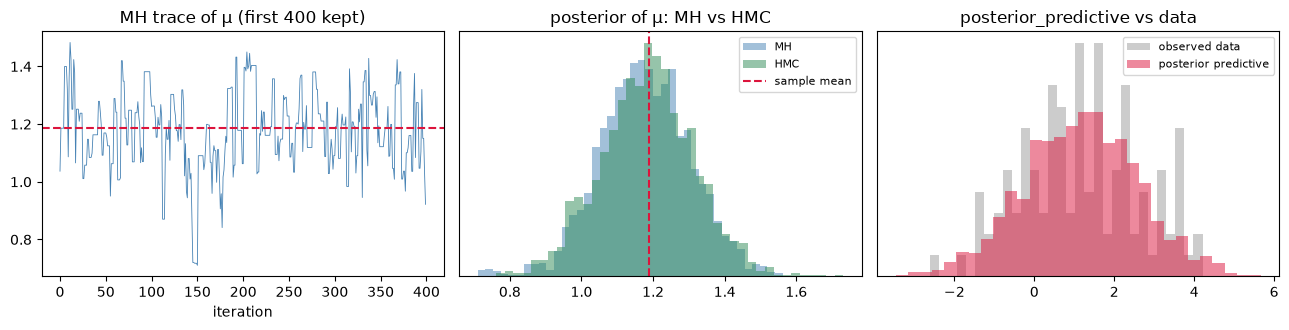

In [11]:
mt, ht, pp = mh.sample_array()[:, 0], hmc.sample_array()[:, 0], np.array(pred)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(mt[:400], lw=0.6, color='steelblue'); ax[0].axhline(xs.mean(), color='crimson', ls='--')
ax[0].set_title('MH trace of µ (first 400 kept)'); ax[0].set_xlabel('iteration')
ax[1].hist(mt, bins=40, density=True, alpha=0.5, color='steelblue', label='MH')
ax[1].hist(ht, bins=40, density=True, alpha=0.5, color='seagreen', label='HMC')
ax[1].axvline(xs.mean(), color='crimson', ls='--', label='sample mean')
ax[1].set_title('posterior of µ: MH vs HMC'); ax[1].legend(fontsize=8); ax[1].set_yticks([])
ax[2].hist(xs, bins=30, density=True, alpha=0.4, color='gray', label='observed data')
ax[2].hist(pp, bins=30, density=True, alpha=0.5, color='crimson', label='posterior predictive')
ax[2].set_title('posterior_predictive vs data'); ax[2].legend(fontsize=8); ax[2].set_yticks([])
fig.tight_layout(); plt.show()

## Convergence: multiple chains and proposal mixtures

A single chain can look converged while stuck. Running several chains from different seeds and checking they agree (a poor-man's R̂) is the standard guard. And proposals compose: a `MixtureProposal` of a small and a large random walk explores both locally and globally in one chain.


In [12]:
from mixle.inference.mcmc import MixtureProposal, RandomWalkProposal

# four independent chains; if they agree, the posterior is well-identified
chain_means = []
for s in range(4):
    r = sample_parameter_posterior(GaussianDistribution(0.0, 1.0), data[:500],
                                   sampler='mh', steps=1500, burn_in=400, seed=s)
    chain_means.append(r.sample_array()[:, 0].mean())
chain_means = np.array(chain_means)
print('per-chain posterior mean of mu:', np.round(chain_means, 3))
print('between-chain spread: %.4f (small => chains agree)' % chain_means.std())

# a mixture of a fine and a coarse random walk
xs = np.array(data); log_target = lambda th: -0.5 / 2.0 * np.sum((xs - th[0]) ** 2)
mix_prop = MixtureProposal([RandomWalkProposal(0.05), RandomWalkProposal(0.5)])
r = metropolis_hastings(log_target, np.array([0.0]), mix_prop, num_samples=2000, burn_in=500, rng=np.random.RandomState(1))
print('MixtureProposal acceptance: %.2f' % r.acceptance_rate)

per-chain posterior mean of mu: [1.183 1.173 1.194 1.162]
between-chain spread: 0.0117 (small => chains agree)
MixtureProposal acceptance: 0.60
